In [19]:
import pandas as pd
import seaborn as sns

df1 = pd.read_csv('city_day.csv')
df2 = pd.read_csv('crop_production.csv')

print("1st dataset")
print(df1.head())
print("2nd dataset")
print(df2.head())


1st dataset
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  
2nd dataset
                    State_Name District_Name  Crop_Year       Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
1  Andaman and Nicoba

In [25]:
print("1st dataset")
print(df1.shape)
print("2nd dataset")
print(df2.shape)

1st dataset
(29531, 16)
2nd dataset
(246091, 7)


In [27]:
print("1st dataset")
print(df1.info)
print("2nd dataset")
print(df2.info)

1st dataset
<bound method DataFrame.info of                 City        Date  PM2.5   PM10     NO    NO2    NOx    NH3  \
0          Ahmedabad  2015-01-01    NaN    NaN   0.92  18.22  17.15    NaN   
1          Ahmedabad  2015-01-02    NaN    NaN   0.97  15.69  16.46    NaN   
2          Ahmedabad  2015-01-03    NaN    NaN  17.40  19.30  29.70    NaN   
3          Ahmedabad  2015-01-04    NaN    NaN   1.70  18.48  17.97    NaN   
4          Ahmedabad  2015-01-05    NaN    NaN  22.10  21.42  37.76    NaN   
...              ...         ...    ...    ...    ...    ...    ...    ...   
29526  Visakhapatnam  2020-06-27  15.02  50.94   7.68  25.06  19.54  12.47   
29527  Visakhapatnam  2020-06-28  24.38  74.09   3.42  26.06  16.53  11.99   
29528  Visakhapatnam  2020-06-29  22.91  65.73   3.45  29.53  18.33  10.71   
29529  Visakhapatnam  2020-06-30  16.64  49.97   4.05  29.26  18.80  10.03   
29530  Visakhapatnam  2020-07-01  15.00  66.00   0.40  26.85  14.05   5.20   

          CO    SO2

In [29]:
print("1st dataset")
print(df1.describe())
print("2nd dataset")
print(df2.describe())

1st dataset
              PM2.5          PM10            NO           NO2           NOx  \
count  24933.000000  18391.000000  25949.000000  25946.000000  25346.000000   
mean      67.450578    118.127103     17.574730     28.560659     32.309123   
std       64.661449     90.605110     22.785846     24.474746     31.646011   
min        0.040000      0.010000      0.020000      0.010000      0.000000   
25%       28.820000     56.255000      5.630000     11.750000     12.820000   
50%       48.570000     95.680000      9.890000     21.690000     23.520000   
75%       80.590000    149.745000     19.950000     37.620000     40.127500   
max      949.990000   1000.000000    390.680000    362.210000    467.630000   

                NH3            CO           SO2            O3       Benzene  \
count  19203.000000  27472.000000  25677.000000  25509.000000  23908.000000   
mean      23.483476      2.248598     14.531977     34.491430      3.280840   
std       25.684275      6.962884     1

In [31]:
#checking null values
df1.isnull().sum()
df2.isnull().sum()


State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

In [33]:
#checking if there is duplicate values
df1.duplicated().sum()
df2.duplicated().sum()


0

In [37]:
#Checking unique values
for col in df1.select_dtypes(include='object'):
    print(f"{col}: {df1[col].nunique()} unique values")

City: 26 unique values
Date: 2009 unique values
AQI_Bucket: 6 unique values


# Task 2 – Missing Value Treatment Strategy

## Dataset 1 (city_day.csv)

### Columns Dropped
- **Xylene**, **PM10**, and **NH3** were removed because they contained a very large number of missing values. Imputing such a large proportion of missing data could reduce reliability and introduce significant uncertainty.

### Numerical Columns Imputed
- **PM2.5, NO, NO2, NOx, CO, SO2, O3, Benzene, Toluene, and AQI** were imputed using the **median**.
- Median was chosen instead of mean because air-quality measurements often contain outliers and skewed distributions.

### Categorical Columns Imputed
- **AQI_Bucket** is a categorical variable and was imputed using the **mode** (most frequent category).

## Dataset 2 (crop_production.csv)

### Numerical Columns Imputed
- **Production** was imputed using the **median**.
- Agricultural production values can vary substantially across crops and districts, making the median more robust than the mean.

### Verification
Null counts were checked before and after treatment to confirm that missing values were successfully handled.


In [39]:
#TASK TWO

In [42]:
print("Dataset 1 Missing Values")
print(df1.isnull().sum())

print("\nDataset 2 Missing Values")
print(df2.isnull().sum())

Dataset 1 Missing Values
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Dataset 2 Missing Values
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


In [44]:
#droping columns
df1 = df1.drop(columns=['Xylene', 'PM10', 'NH3'])

In [46]:
num_cols = ['PM2.5', 'NO', 'NO2', 'NOx', 'CO',
            'SO2', 'O3', 'Benzene', 'Toluene', 'AQI']

for col in num_cols:
    df1[col] = df1[col].fillna(df1[col].median())

In [48]:
df1['AQI_Bucket'] = df1['AQI_Bucket'].fillna(
    df1['AQI_Bucket'].mode()[0]
)

In [50]:
df2['Production'] = df2['Production'].fillna(
    df2['Production'].median()
)

In [52]:
print("Before Treatment")
print(df1.isnull().sum())
print(df2.isnull().sum())

Before Treatment
City          0
Date          0
PM2.5         0
NO            0
NO2           0
NOx           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


In [54]:
print("After Treatment")
print(df1.isnull().sum())
print(df2.isnull().sum())

After Treatment
City          0
Date          0
PM2.5         0
NO            0
NO2           0
NOx           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


# Task 3 – State Name Standardization and Duplicate Removal

## Inconsistencies Checked
- Leading and trailing spaces in state names
- Inconsistent capitalization
- Historical or alternate state names (e.g., Orissa vs Odisha)

## Fixes Applied
- Removed extra spaces using `str.strip()`
- Standardized capitalization using `str.title()`
- Replaced known historical names with modern equivalents using a mapping dictionary

## Duplicate Records
- Dataset 1 duplicate rows found: **0**
- Dataset 2 duplicate rows found: **0**

Since no duplicates were detected, no rows were removed.

## Why This Matters
Datasets can only be merged reliably when key values match exactly. Differences in spelling, spacing, or naming conventions can cause records to fail to match during a merge operation.


In [56]:
#TASK #

In [60]:
# Check Unique State Names
print(sorted(df2['State_Name'].unique()))

['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir ', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana ', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [62]:
#Clean State Names
df2['State_Name'] = df2['State_Name'].str.strip()
df2['State_Name'] = df2['State_Name'].str.title()

In [64]:
# Fix Known Variants
state_fixes = {
    'Orissa': 'Odisha',
    'Uttaranchal': 'Uttarakhand',
    'Pondicherry': 'Puducherry',
    'Andaman & Nicobar Islands': 'Andaman And Nicobar Islands'
}

df2['State_Name'] = df2['State_Name'].replace(state_fixes)

In [66]:
#finding duplicates
print("Dataset 1 duplicates:", df1.duplicated().sum())
print("Dataset 2 duplicates:", df2.duplicated().sum())

Dataset 1 duplicates: 0
Dataset 2 duplicates: 0


In [70]:
print("Dataset 1 rows before:", len(df1))
df1 = df1.drop_duplicates()
print("Dataset 1 rows after:", len(df1))

print("Dataset 2 rows before:", len(df2))
df2 = df2.drop_duplicates()
print("Dataset 2 rows after:", len(df2))

Dataset 1 rows before: 29531
Dataset 1 rows after: 29531
Dataset 2 rows before: 246091
Dataset 2 rows after: 246091


In [72]:
print(sorted(df2['State_Name'].unique()))

['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra And Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


# Task 4 – AQI Distribution Analysis

## Choice of Visualisations

Two visualisations were selected:

1. **Histogram**
   - Shows how AQI values are distributed.
   - Helps identify where most cities are concentrated on the AQI scale.

2. **Boxplot**
   - Reveals the spread of AQI values.
   - Highlights potential outliers and extreme pollution readings.

Using both plots provides a complete picture of the AQI distribution.

## Observations

1. The **mean AQI is 158.78**, while the **median AQI is 118.00**. Since the mean is much higher than the median, the distribution is positively skewed.

2. The boxplot indicates the presence of extreme AQI values. These extreme values increase the average AQI, making the median a more representative measure of a typical city's air quality.

## Conclusion

Most cities appear to have AQI values below the reported average, suggesting that a relatively small number of highly polluted observations are pulling the mean upward.


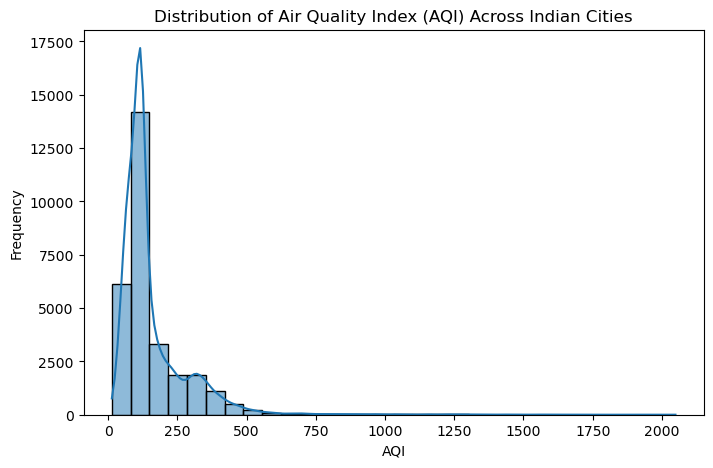

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df1['AQI'], bins=30, kde=True)

plt.title("Distribution of Air Quality Index (AQI) Across Indian Cities")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

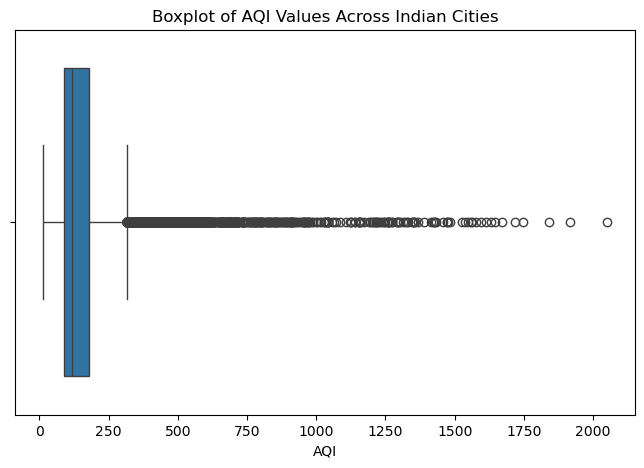

In [76]:
# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df1['AQI'])

plt.title("Boxplot of AQI Values Across Indian Cities")
plt.xlabel("AQI")
plt.show()

In [78]:
print("Mean AQI:", df1['AQI'].mean())
print("Median AQI:", df1['AQI'].median())

Mean AQI: 158.78155158985473
Median AQI: 118.0


In [80]:
print(df1['AQI'].mean())
print(df1['AQI'].median())

158.78155158985473
118.0


# Task 5 – Outlier Detection and Treatment

## Detection Method

The **Interquartile Range (IQR) method** was used.

Formulas:

- IQR = Q3 − Q1
- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Values outside these bounds were classified as outliers.

## Why This Method?

AQI data is positively skewed and contains extreme values. The IQR method is robust and does not assume a normal distribution.

## Results

- Total outliers detected: **3192**
- Total values treated: **3192**

## Treatment Applied

Outliers were **capped (winsorized)** using the calculated upper and lower bounds rather than removed.

Reasons:
- Preserves all records.
- Reduces the influence of implausible values.
- Prevents extreme observations from distorting statistical analyses and machine learning models.

## Evidence

Boxplots were generated before and after treatment to visually compare the distribution.

## Conclusion

The dataset contained a substantial number of extreme AQI values. Capping these values reduced their impact while retaining all observations.


In [82]:
#For Task 5, the best approach is the IQR Method
Q1 = df1['AQI'].quantile(0.25)
Q3 = df1['AQI'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df1[(df1['AQI'] < lower_bound) |
               (df1['AQI'] > upper_bound)]

print("Number of outliers:", len(outliers))

Number of outliers: 3192


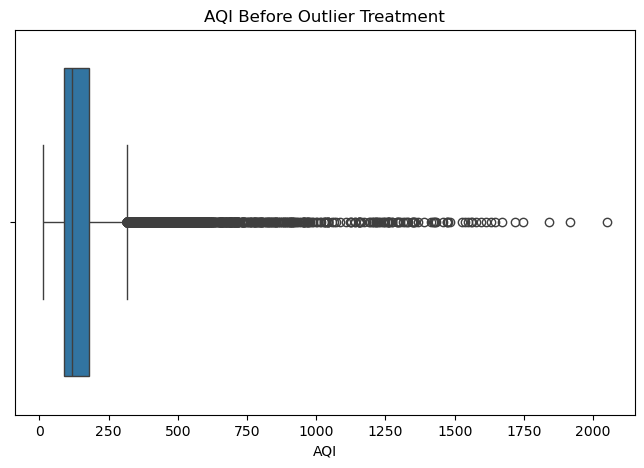

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df1['AQI'])
plt.title("AQI Before Outlier Treatment")
plt.xlabel("AQI")
plt.show()

In [90]:
#Count Values Affected
df1['AQI_clean'] = df1['AQI']

df1['AQI_clean'] = df1['AQI_clean'].clip(
    lower=lower_bound,
    upper=upper_bound
)

In [92]:
affected = ((df1['AQI'] < lower_bound) |
            (df1['AQI'] > upper_bound)).sum()

print("Values affected:", affected)

Values affected: 3192


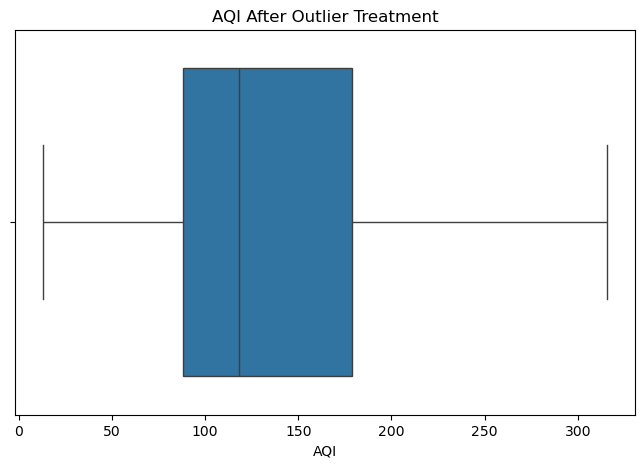

In [94]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df1['AQI_clean'])
plt.title("AQI After Outlier Treatment")
plt.xlabel("AQI")
plt.show()

In [96]:
print("Before Treatment")
print(df1['AQI'].describe())

print("\nAfter Treatment")
print(df1['AQI_clean'].describe())

Before Treatment
count    29531.000000
mean       158.781552
std        130.272413
min         13.000000
25%         88.000000
50%        118.000000
75%        179.000000
max       2049.000000
Name: AQI, dtype: float64

After Treatment
count    29531.000000
mean       145.047205
std         82.612919
min         13.000000
25%         88.000000
50%        118.000000
75%        179.000000
max        315.500000
Name: AQI_clean, dtype: float64


In [98]:
print("Number of outliers:", len(outliers))

Number of outliers: 3192


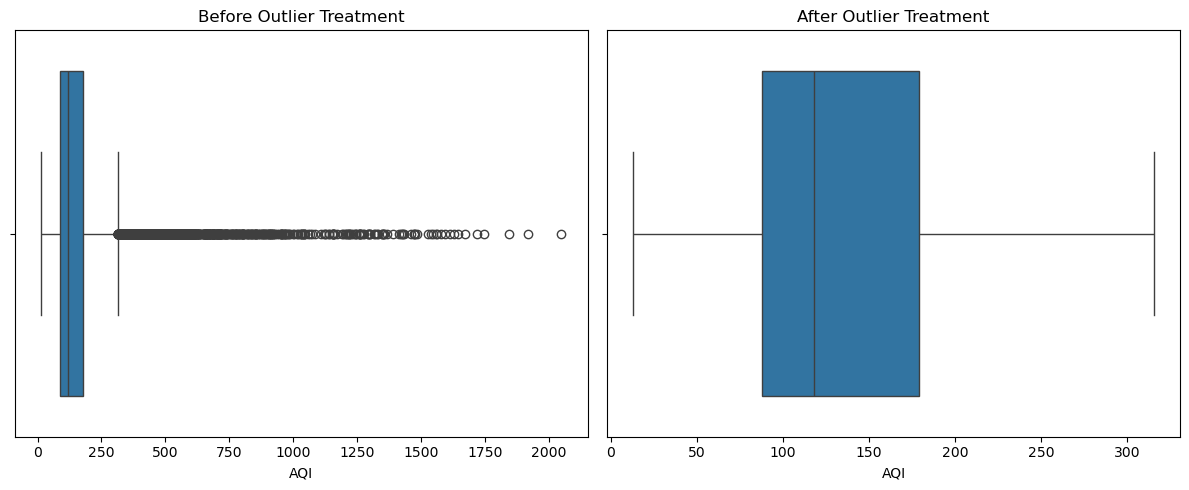

In [102]:
#the before and after boxplots side by side
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(x=df1['AQI'], ax=axes[0])
axes[0].set_title("Before Outlier Treatment")
axes[0].set_xlabel("AQI")

sns.boxplot(x=df1['AQI_clean'], ax=axes[1])
axes[1].set_title("After Outlier Treatment")
axes[1].set_xlabel("AQI")

plt.tight_layout()
plt.show()